In [4]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from opacus import PrivacyEngine

In [5]:
df = pd.read_csv("depression.csv")
print("Shape:", df.shape)
df.head()

Shape: (38627, 41)


,full_name,email,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,...,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10
0,Jennifer Davis,theresa92@example.com,High school,Urban,Female,No,Small screen,Unique network,Right,Other,...,1,5,7,7,7,7,7,5,1,1
1,Jack Kelley,ehernandez@example.net,High school,Urban,Female,Yes,Big screen,Unique network,Left,Christian (Other),...,6,5,4,7,5,4,7,7,1,5
2,Trevor Rivera,bsmith@example.net,High school,Urban,Female,No,Big screen,Unique network,Right,Christian (Catholic),...,2,5,2,2,5,6,5,5,3,2
3,Erika Hopkins,buckdavid@example.org,Less than high school,Urban,Female,Yes,Big screen,Unique network,Left,Christian (Catholic),...,1,1,7,4,6,4,6,1,6,1
4,Charles Odom,simmonstammy@example.org,University degree,Suburban,Female,No,Big screen,Shared network,Both,Muslim,...,2,5,3,6,5,5,5,6,3,3



✅ Test Accuracy: 0.2497

📊 Classification Report (Test Set):
                  precision    recall  f1-score   support

Extremely Severe       0.00      0.00      0.00     11209
            Mild       0.00      0.00      0.00      4106
        Moderate       0.00      0.00      0.00      7107
          Normal       0.25      1.00      0.40      9644
          Severe       0.00      0.00      0.00      6561

        accuracy                           0.25     38627
       macro avg       0.05      0.20      0.08     38627
    weighted avg       0.06      0.25      0.10     38627



C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

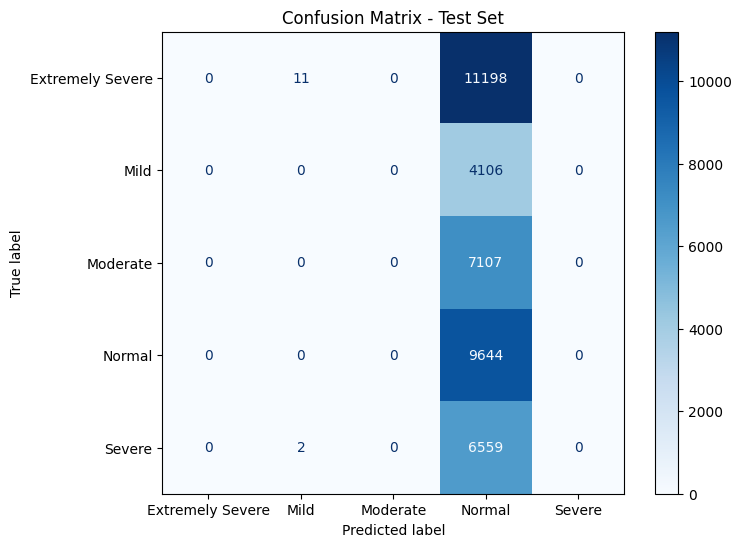

In [6]:
import pandas as pd
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch.nn as nn

# -------------------------------
# Load test dataset
# -------------------------------
df_test = pd.read_csv("depression.csv")

# Depression question columns (same as training)
depression_qs = ['Q3A', 'Q5A', 'Q10A', 'Q13A', 'Q16A', 'Q17A', 'Q21A',
                 'Q24A', 'Q26A', 'Q31A', 'Q34A', 'Q37A', 'Q38A']
depression_df = df_test[depression_qs].copy()

depression_df = depression_df.apply(pd.to_numeric, errors='coerce') - 1
depression_df['Total_Count'] = depression_df.sum(axis=1)

def get_condition(score):
    if score <= 9:
        return 'Normal'
    elif 10 <= score <= 13:
        return 'Mild'
    elif 14 <= score <= 20:
        return 'Moderate'
    elif 21 <= score <= 27:
        return 'Severe'
    else:
        return 'Extremely Severe'

depression_df['Condition'] = depression_df['Total_Count'].apply(get_condition)
df_test['Condition'] = depression_df['Condition']

# -------------------------------
# Encode the dataset
# -------------------------------
target_column = 'Condition'
df_encoded = df_test.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include='object').columns:
    if col != target_column:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

le_target = LabelEncoder()
df_encoded[target_column] = le_target.fit_transform(df_encoded[target_column])

# -------------------------------
# Ensure same 38 training features (provide exact list)
# -------------------------------
trained_features = ['gender', 'age', 'education', 'employment', 'income', 'residence', 
                    'Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A', 'Q7A', 'Q8A', 'Q9A', 'Q10A',
                    'Q11A', 'Q12A', 'Q13A', 'Q14A', 'Q15A', 'Q16A', 'Q17A', 'Q18A',
                    'Q19A', 'Q20A', 'Q21A', 'Q22A', 'Q23A', 'Q24A', 'Q25A', 'Q26A',
                    'Q27A', 'Q28A', 'Q29A', 'Q30A', 'Q31A', 'Q32A']  # replace with actual 38 features

# If some features are missing in the test set, fill them with 0 (just to avoid KeyErrors)
for col in trained_features:
    if col not in df_encoded.columns:
        df_encoded[col] = 0

X_test = df_encoded[trained_features]
y_test = df_encoded[target_column]

# -------------------------------
# Convert to tensor
# -------------------------------
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# -------------------------------
# Define same model as during training
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_test_tensor.shape[1]
num_classes = len(np.unique(y_test_tensor))

model = MLP(input_dim, num_classes)
model.load_state_dict(torch.load("trained_global_model_3.pth"))
model.eval()

# -------------------------------
# Predict & Evaluate
# -------------------------------
with torch.no_grad():
    y_pred = model(X_test_tensor).argmax(dim=1)

test_acc = accuracy_score(y_test_tensor, y_pred)
print(f"\n✅ Test Accuracy: {test_acc:.4f}\n")

print("📊 Classification Report (Test Set):")
print(classification_report(y_test_tensor, y_pred, target_names=le_target.classes_))

# -------------------------------
# Plot confusion matrix
# -------------------------------
cm = confusion_matrix(y_test_tensor, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Test Set")
plt.show()
